# Active learning with STACNotator

This notebook walks through one full active-learning round against a STACNotator campaign:

1. Log in via the browser and open a campaign
2. Fetch the labeled samples and split them into train/test
3. Train a deliberately simple model (lat/lon as the only features)
4. Predict over a pixel grid covering the campaign extent and write the result as a COG
5. Register the prediction as a map layer with a class legend, so annotators see where the model is confused
6. Queue the locations the model is least sure about as a new task set for annotators
7. After annotators add labels, grow the training set with `update_samples` and retrain

The lat/lon model is a stand-in: it only demonstrates the data plumbing. In a real setup you
would featurize with raster bands or embeddings; loading raster data through the SDK is on the
roadmap (see the README TODOs).

In [11]:
# The SDK is not on PyPI yet; install it from this repo checkout
# (this notebook lives in sdk/examples/, the package root sdk/ is one dir up).
%pip install -q .. scikit-learn shapely matplotlib

Note: you may need to restart the kernel to use updated packages.


## 1. Login and pick a campaign

`login` opens your browser once and caches the credential locally. Against a local dev
backend (`AUTH_PROVIDER=local`) it just works without a browser.

In [1]:
import stacnotator as snt

URL = "http://localhost:5173"  # your STACNotator app URL

snt.login(URL)
snt.campaigns()

pci id for fd 5: 10de:28a0, driver (null)
pci id for fd 6: 10de:28a0, driver (null)
pci id for fd 7: 10de:28a0, driver (null)
pci id for fd 6: 10de:28a0, driver (null)
pci id for fd 7: 10de:28a0, driver (null)


Opening in existing browser session.


,id,name,created_at,is_admin,is_member,is_public
0,91,venezuela earthquake,2026-07-01T15:38:34.085078,True,True,False
1,83,test-landsat-viz,2026-06-08T13:46:18.466163,True,True,False
2,82,Bungoma_cropland,2026-06-08T07:08:49.798690,True,True,False
3,81,BR_Pasture_subStrata_n1575_2000-2025,2026-06-05T19:04:24.763447,True,True,False
4,80,Ukraine_WinterCrops_20260605,2026-06-05T13:53:22.961535,True,True,False
5,74,BR-Pasture_subStrata_2000-2025,2026-06-02T17:57:44.630379,True,True,False
6,71,Programa Escuelas Rurales 2026,2026-06-02T09:47:01.012571,True,True,False
7,69,"Kenya, Muranga County - Cropland 2025-2026",2026-05-21T05:47:37.850658,True,True,False
8,66,Maryland Solar Farm Validation (BWM 2026 UMDGC...,2026-05-14T15:01:17.174609,True,True,False
9,63,"Kenya, Bungoma County - Cropland 2025-2026",2026-05-06T22:10:52.345540,True,True,False


In [2]:
CAMPAIGN_ID = 91  # pick one from the table above

campaign = snt.campaign(CAMPAIGN_ID)
print(campaign)
print("labels:", campaign.labels)
print("extent:", campaign.extent)

Campaign(id=91, name='venezuela earthquake', mode='open')
labels: {1: 'damaged', 2: 'non-damaged', 3: 'other'}
extent: (-73.4, 0.6, -59.8, 12.2)


## 2. Fetch samples and split

One row per labeled annotation. The test set is held out once and stays fixed for the whole
campaign, so scores are comparable across rounds.

In [3]:
from sklearn.model_selection import train_test_split

samples = campaign.get_samples()
print(f"{len(samples)} labeled samples")
samples.head()

233 labeled samples


,annotation_id,task_id,lat,lon,label_id,label,confidence,annotator,created_at,geometry
0,56142,<NA>,NaN,NaN,2,non-damaged,<NA>,local@localhost,2026-07-03 08:08:33.560421+00:00,"{'type': 'Polygon', 'coordinates': [[[-67.5978..."
1,56143,<NA>,NaN,NaN,2,non-damaged,<NA>,local@localhost,2026-07-03 08:08:40.719134+00:00,"{'type': 'Polygon', 'coordinates': [[[-67.5965..."
2,56144,<NA>,NaN,NaN,2,non-damaged,<NA>,local@localhost,2026-07-03 08:08:45.989883+00:00,"{'type': 'Polygon', 'coordinates': [[[-67.5966..."
3,56145,<NA>,NaN,NaN,2,non-damaged,<NA>,local@localhost,2026-07-03 08:08:52.715732+00:00,"{'type': 'Polygon', 'coordinates': [[[-67.5919..."
4,56146,<NA>,NaN,NaN,1,damaged,<NA>,local@localhost,2026-07-03 08:09:00.426665+00:00,"{'type': 'Polygon', 'coordinates': [[[-67.5962..."


In [4]:
train, test = train_test_split(samples, test_size=0.2, random_state=42)
len(train), len(test)

(186, 47)

## 3. Train a very simple model

The only features are lon/lat. The SDK hands geometries over as they are, so reducing
them to coordinates is our job here: point samples already carry lat/lon, polygon and box
samples are reduced to their centroid.

In [5]:
import numpy as np
from shapely.geometry import shape
from sklearn.ensemble import RandomForestClassifier


def featurize(df):
    centroids = df["geometry"].map(lambda g: shape(g).centroid)
    lon = df["lon"].fillna(centroids.map(lambda c: c.x))
    lat = df["lat"].fillna(centroids.map(lambda c: c.y))
    return np.column_stack([lon, lat]), df["label_id"].to_numpy(dtype="int64")


model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(*featurize(train))
print(f"held-out accuracy: {model.score(*featurize(test)):.2f}")

held-out accuracy: 0.98


## 4. Predict a dense class map over the campaign extent

The model is evaluated on every pixel of a regular grid covering the extent. With lat/lon as
the only features, the toy model paints a few large uniform sectors - a boring demo map. So
before taking the argmax, each class probability gets nudged by a smooth multi-scale random
field: class regions break up into organic, landcover-looking patches while still following
the model where it is confident. Set `NOISE_STRENGTH = 0` for the raw model map; with a real
model, that is what you want. `PIXEL_SIZE_DEG` sets the resolution; coarser pixels mean a
smaller file and faster prediction.

In [6]:
import numpy as np
from scipy.ndimage import gaussian_filter

PIXEL_SIZE_DEG = 0.05  # make this smaller for a finer map

west, south, east, north = campaign.extent
width = max(2, int(np.ceil((east - west) / PIXEL_SIZE_DEG)))
height = max(2, int(np.ceil((north - south) / PIXEL_SIZE_DEG)))

lons = np.linspace(west, east, width)
lats = np.linspace(north, south, height)  # north up: first row is the top
grid = np.column_stack([np.tile(lons, height), np.repeat(lats, width)])

proba = model.predict_proba(grid).reshape(height, width, -1)


def landcover_noise(rng, octaves=((3, 0.2), (10, 0.5), (30, 1.0))):
    """Smooth random field mixing large blobs (sigma 30) with finer texture."""
    field = np.zeros((height, width))
    for sigma, weight in octaves:
        octave = gaussian_filter(rng.standard_normal((height, width)), sigma=sigma)
        field += weight * octave / octave.std()
    return field / field.std()


NOISE_STRENGTH = 0.5  # 0 -> raw model prediction
rng = np.random.default_rng(42)
noise = np.stack([landcover_noise(rng) for _ in model.classes_], axis=-1)
class_raster = model.classes_[np.argmax(proba + NOISE_STRENGTH * noise, axis=-1)].astype("uint8")
print(f"{width} x {height} pixels, classes {np.unique(class_raster)}")

273 x 232 pixels, classes [1 2 3]


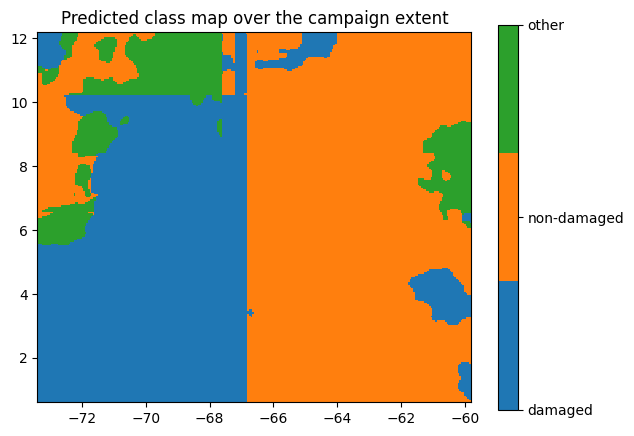

In [7]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

class_ids = sorted(campaign.labels)
cmap = ListedColormap(plt.get_cmap("tab10").colors[: len(class_ids)])

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(class_raster, extent=(west, east, south, north), cmap=cmap, interpolation="nearest")
colorbar = fig.colorbar(im, ticks=class_ids)
colorbar.ax.set_yticklabels([campaign.labels[i] for i in class_ids])
ax.set_title("Predicted class map over the campaign extent")
plt.show()

## 5. Write the prediction as a COG and register it

`snt.utils.array_to_cog` turns the predicted array plus the campaign extent into a valid
Cloud-Optimized GeoTIFF (tiled, compressed, with overviews so it renders fast at every zoom).
If your pipeline produces many inference chips instead of one array, `snt.utils.merge_to_cog`
mosaics a whole folder of them into a single COG, and `snt.utils.to_cog` converts a GeoTIFF
you already have.

The tiler fetches the file by URL, so after writing it locally, upload it anywhere the tiler
can reach (an Azure blob with a SAS token, an S3 presigned URL, any public file host) and put
that URL in `COG_URL`.

In [7]:
cog_path = snt.utils.array_to_cog(class_raster, campaign.extent, "predictions.cog.tif")
print(f"wrote {cog_path}; upload it and set COG_URL below")

wrote predictions.cog.tif; upload it and set COG_URL below


In [ ]:
# The tiler fetches this URL, so it must NOT be a local file path.
# - hosted: an Azure blob SAS / S3 presigned / public URL
# - local dev tiler: run `python3 -m http.server 8091` in this folder and use
#   http://host.docker.internal:8091/predictions.cog.tif (how the tiler container sees your machine)
COG_URL = "https://<your-storage>/predictions.cog.tif?<sas-token>"

layer = campaign.register_overlay(
    COG_URL,
    classes=campaign.labels,  # class values match label ids, legend shows label names
)
layer

### Local dev alternative: write straight into the tiler's folder

If your dev stack runs the tiler profile (`COMPOSE_PROFILES=tiler` in `.env`), the tiler
mounts the repo's `cogs/` folder read-only at `/data/cogs` and reads files from there
directly - no upload, no file server. Write the COG into that folder and register the
tiler-local path; run this instead of the hosted-URL cell above.

In [8]:
from pathlib import Path

cogs_dir = Path("../../cogs")  # <repo>/cogs, mounted into the dev tiler at /data/cogs
cogs_dir.mkdir(exist_ok=True)
local_cog = snt.utils.array_to_cog(class_raster, campaign.extent, cogs_dir / "predictions.cog.tif")

layer = campaign.register_overlay(
    f"/data/cogs/{local_cog.name}",
    classes=campaign.labels,
)
layer

{'id': 6,
 'campaign_id': 91,
 'name': 'overlay-1',
 'cog_url': '/data/cogs/predictions.cog.tif',
 'render_config': {'mode': 'categorical',
  'band': 1,
  'nodata': None,
  'colormap_name': None,
  'rescale': None,
  'entries': [{'value': 1, 'color': '#1b9e77', 'label': 'damaged'},
   {'value': 2, 'color': '#d95f02', 'label': 'non-damaged'},
   {'value': 3, 'color': '#7570b3', 'label': 'other'}]},
 'max_native_zoom': None,
 'status': 'registering',
 'status_error': None,
 'tile_url': None,
 'mosaic_id': None,
 'display_order': 0,
 'mlops_url': None,
 'internal_storage': False}

In [10]:
# Registration runs asynchronously on the server; re-run until status is "ready".
campaign.overlays()

,id,name,cog_url,status,mlops_url,tile_url
0,6,overlay-1,/data/cogs/predictions.cog.tif,ready,None,http://localhost:8001/searches/c4dce1acbb57206...


## 6. Queue the most uncertain locations as a new task set

The overlay shows annotators where the model is confused, but they still have to hunt for
those spots themselves. Task sets close that loop: pick the grid points where the model is
least confident and upload them as a named task set. Each round gets its own set, so its
progress is tracked separately and annotators can filter Task Mode to exactly this batch.

`upload_tasks` takes a DataFrame with `lat`/`lon` columns (extra columns are kept on the
task and round-trip into exports). `create_missing=True` creates the set if it does not
exist yet; without it, unknown names raise so a typo cannot silently create a stray set.

In [ ]:
import pandas as pd

N_QUERIES = 25  # how many locations to send to annotators this round

# Uncertainty = 1 - max class probability, on the same grid as the class map.
uncertainty = 1 - proba.reshape(len(grid), -1).max(axis=1)

most_uncertain = np.argsort(uncertainty)[::-1][:N_QUERIES]
queries = pd.DataFrame(
    {
        "lon": grid[most_uncertain, 0],
        "lat": grid[most_uncertain, 1],
        "uncertainty": uncertainty[most_uncertain].round(3),
    }
)

created = campaign.upload_tasks(queries, task_set="uncertain-round-1", create_missing=True)
print(f"queued {created} tasks in set 'uncertain-round-1'")

In [ ]:
# Per-set progress: num_labeled counts tasks with at least one annotation.
campaign.task_sets()

Annotators now see the prediction overlay with its legend in the annotation UI, and the
queued locations wait for them as their own task set they can filter to in Task Mode.

## 7. Next round: grow the training set and retrain

`update_samples` appends only samples that are new since the last fetch. The held-out test
set is passed as `exclude`, so it never leaks into training.

In [ ]:
before = len(train)
train = campaign.update_samples(train, exclude=test)
print(f"training set: {before} -> {len(train)} samples")

model.fit(*featurize(train))
print(f"held-out accuracy: {model.score(*featurize(test)):.2f}")

From here the loop repeats: predict over the extent, upload, register the next layer (names
auto-number as `overlay-2`, `overlay-3`, ...), queue the next uncertainty batch as
`uncertain-round-2`, wait for annotators, update, retrain.